# Robustness Analysis: Adjoint and Toggle-Frame Objectives Subject to Either Multiplicative or Additive Errors

This notebook compares the performance of the adjoint and toggling-frame robustness objectives for multiplicative and additive error terms in the system's Hamiltonian. 

## Imports

In [36]:
import Pkg; Pkg.activate(@__DIR__); Pkg.instantiate();
Pkg.develop(path="../../QuantumCollocation.jl")
using PiccoloQuantumObjects
using QuantumCollocation
using ForwardDiff
using LinearAlgebra
using Plots
using SparseArrays
using Statistics
using CairoMakie
using Random

  Activating project at `~/Documents/GitHub/robust_control_sam/src`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651
   Resolving package versions...
  No Changes to `~/Documents/GitHub/robust_control_sam/src/Project.toml`
  No Changes to `~/Documents/GitHub/robust_control_sam/src/Manifest.toml`


In [37]:
tr(GATES.X'GATES.X) /2

1.0 + 0.0im

In [69]:
# Problem parameters
T = 40
Δt = 0.2
U_goal = GATES.H
H_drive = [PAULIS.X, PAULIS.Y, PAULIS.Z]
piccolo_opts = PiccoloOptions(verbose=false)
pretty_print(X::AbstractMatrix) = Base.show(stdout, "text/plain", X);
sys = QuantumSystem(H_drive)
seed = 18
F=0.9999
num_iter = 100

100

In [ ]:
# Default
Random.seed!(seed)
def = UnitarySmoothPulseProblem(sys, U_goal, T, Δt; dda_bound=10.0, Q_t=1.0)
push!(def.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, def.trajectory))
solve!(def, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
#solve!(def, max_iter=50, print_level=5)

    constructing UnitarySmoothPulseProblem...
	using integrator: DataType
	control derivative names: [:da, :dda]
	applying timesteps_all_equal constraint: Δt
    initializing optimizer...
        applying constraint: timesteps all equal constraint
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying constraint: bounds on Δt
This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:     4976
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      706
                     variables with only lower bounds:        0
                variables with lower and upper b

Excessive output truncated after 524293 bytes.

 345  4.1128875e-04 1.19e-05 7.07e+01  -4.1 9.69e-02    -  1.00e+00 6.25e-02h  5
 346  4.1121378e-04 1.07e-05 7.07e+01  -4.1 2.74e-02    -  1.00e+00 1.25e-01h  4
 347  4.1421819e-04 1.33e-05 7.07e+01  -4.1 1.22e-02    -  1.00e+00 1.00e+00h  1
 348  4.0923931e-04 2.23e-05 7.07e+01  -4.1 1.13e-02    -  1.00e+00 1.00e+00h  1
 349  4.1284281e-04 1.99e-05 7.07e+01  -4.1 9.16e-02    -  1.00e+00 6.25e-02h  5
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
 350  4.1443029e-04 7.54e-06 7.07e+01  -4.1 1.17e-02    -  1.00e+00 1.00e+00h  1


In [ ]:
# Universal
Random.seed!(seed)
f_uni_prob = UnitaryUniversalProblem(
    sys, U_goal, T, Δt;
    dda_bound=0.1,
    activate_hyperspeed=true,
    piccolo_options=piccolo_opts
    )
#push!(f_uni_prob.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, f_uni_prob.trajectory))
solve!(f_uni_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
#solve!(f_uni_prob, max_iter=50, print_level=5)


In [70]:
# Toggling
F=0.9999
Random.seed!(seed)
Hₑ_add = a -> [PAULIS.X, PAULIS.Y, PAULIS.Z]
Random.seed!(seed)
add_prob = UnitarySmoothPulseProblem(
            sys, U_goal, T, Δt;
            dda_bound=0.1,
            piccolo_options=piccolo_opts,
            activate_rob_loss=true,
            H_err=Hₑ_add,
            Q=0.0,
            Q_t=1.0
        )
#push!(add_prob.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, add_prob.trajectory))
solve!(add_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=true, output_file="tog_log_hessians.txt"))
#solve!(add_prob, max_iter=50, print_level=5)

CompositeException: TaskFailedException

    nested task error: InterruptException:

In [ ]:
# Adjoint, rollout initialization
F=0.9999

Random.seed!(seed)
∂ₑHₐ = PAULIS.X
varsys_add = VariationalQuantumSystem(
    H_drive,
    [PAULIS.X, PAULIS.Y, PAULIS.Z]
)

var_count = length(varsys_add.G_vars)

varadd_prob = UnitaryVariationalProblem(
    varsys_add, U_goal, T, Δt;
    robust_times = [[T] for _ in 1:var_count],
    dda_bound = 0.1,
    Q=0.0,
    Q_r = 1.0/(T^2),   # > 0
    Q_s = 0.0,     # (irrelevant since sensitive_times is empty)
    piccolo_options = PiccoloOptions(verbose=false)
)

init_traj = deepcopy(varadd_prob.trajectory)
init_traj.Ũ⃗ .= unitary_rollout(init_traj, varsys_add)
remove_components(init_traj, [:Ũ⃗ᵥ1, :Ũ⃗ᵥ2, :Ũ⃗ᵥ3])

varadd_prob = UnitaryVariationalProblem(
    varsys_add, U_goal, T, Δt;
    robust_times = [[T] for _ in 1:var_count],
    init_trajectory = init_traj,
    dda_bound = 0.1,
    Q=0.0,
    Q_r = 1.0/(T^2),   # > 0
    Q_s = 0.0,     # (irrelevant since sensitive_times is empty)
    piccolo_options = PiccoloOptions(verbose=false)
)

push!(varadd_prob.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, varadd_prob.trajectory))
#solve!(varadd_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false, output_file="varadd_log.txt"))
solve!(varadd_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(output_file="varadd_log_hessians_two.txt"))

AssertionError: AssertionError: all([name ∉ keys(traj.components) for (name, data) = pairs(comps_data)])

In [76]:
init_traj.names

(:Ũ⃗, :a, :da, :dda, :Δt, :Ũ⃗ᵥ1, :Ũ⃗ᵥ2, :Ũ⃗ᵥ3)

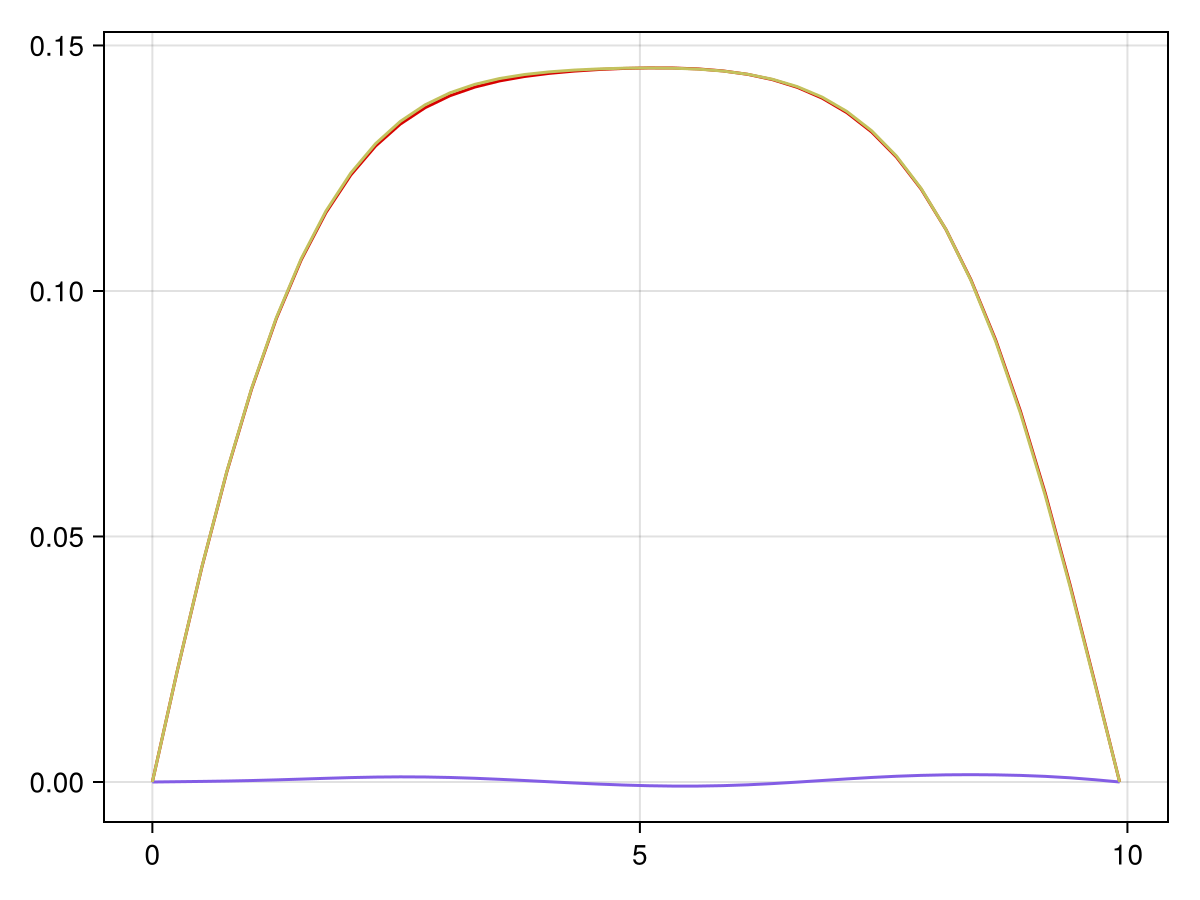

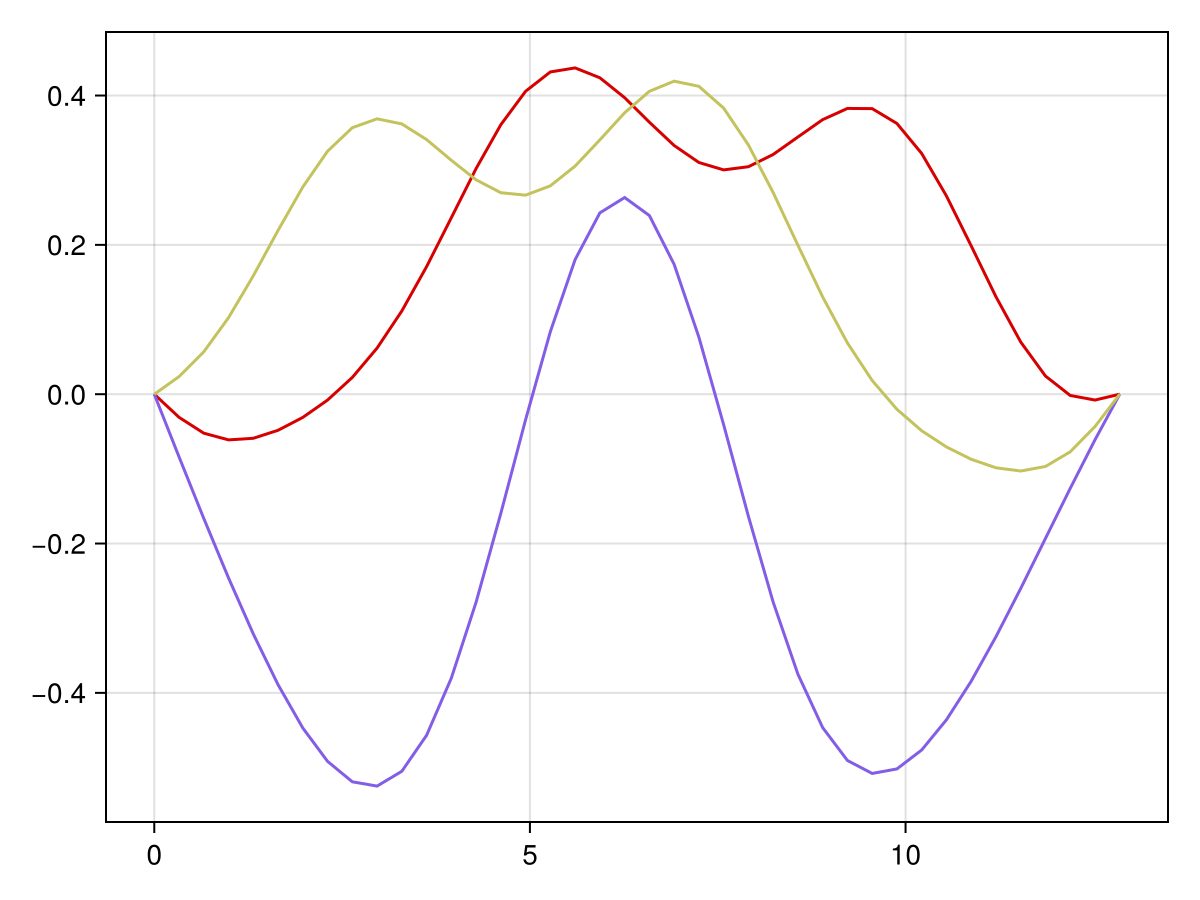

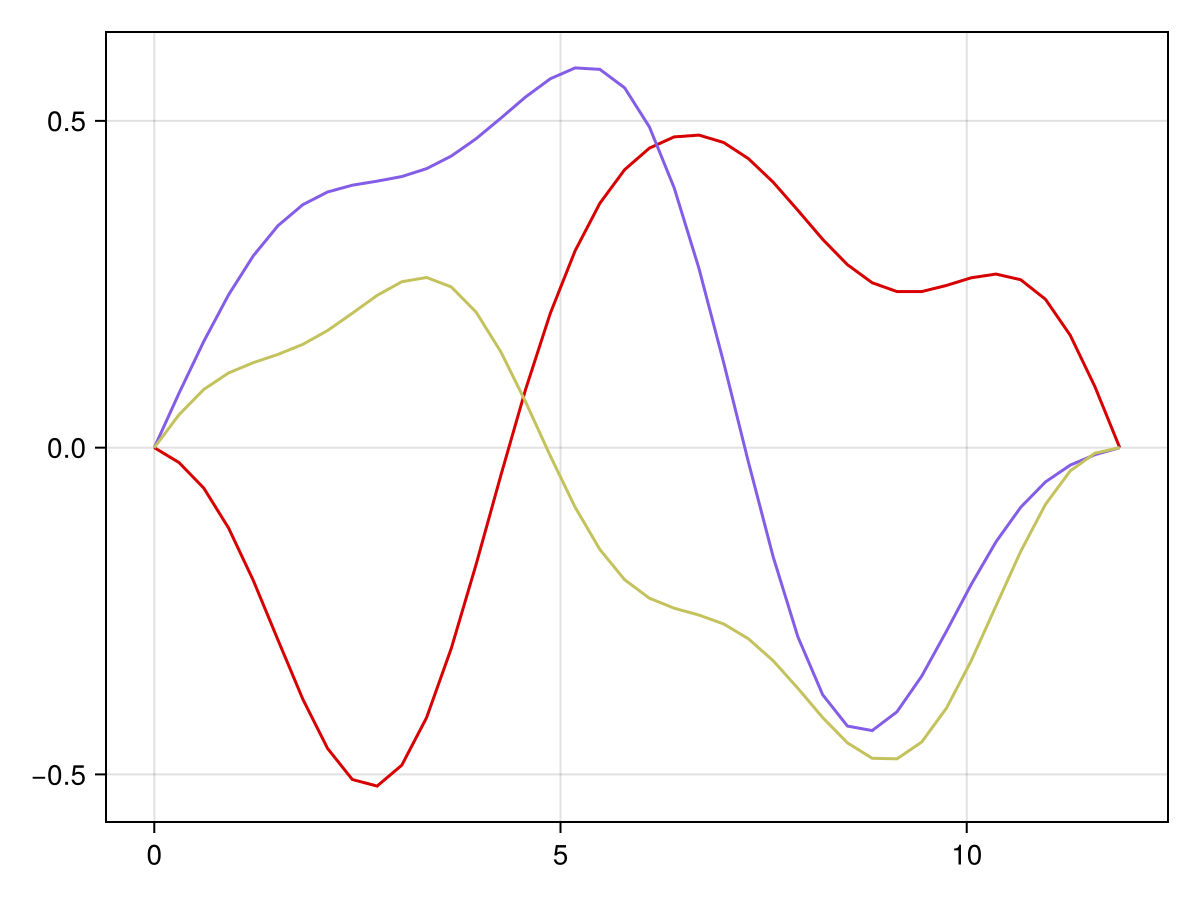

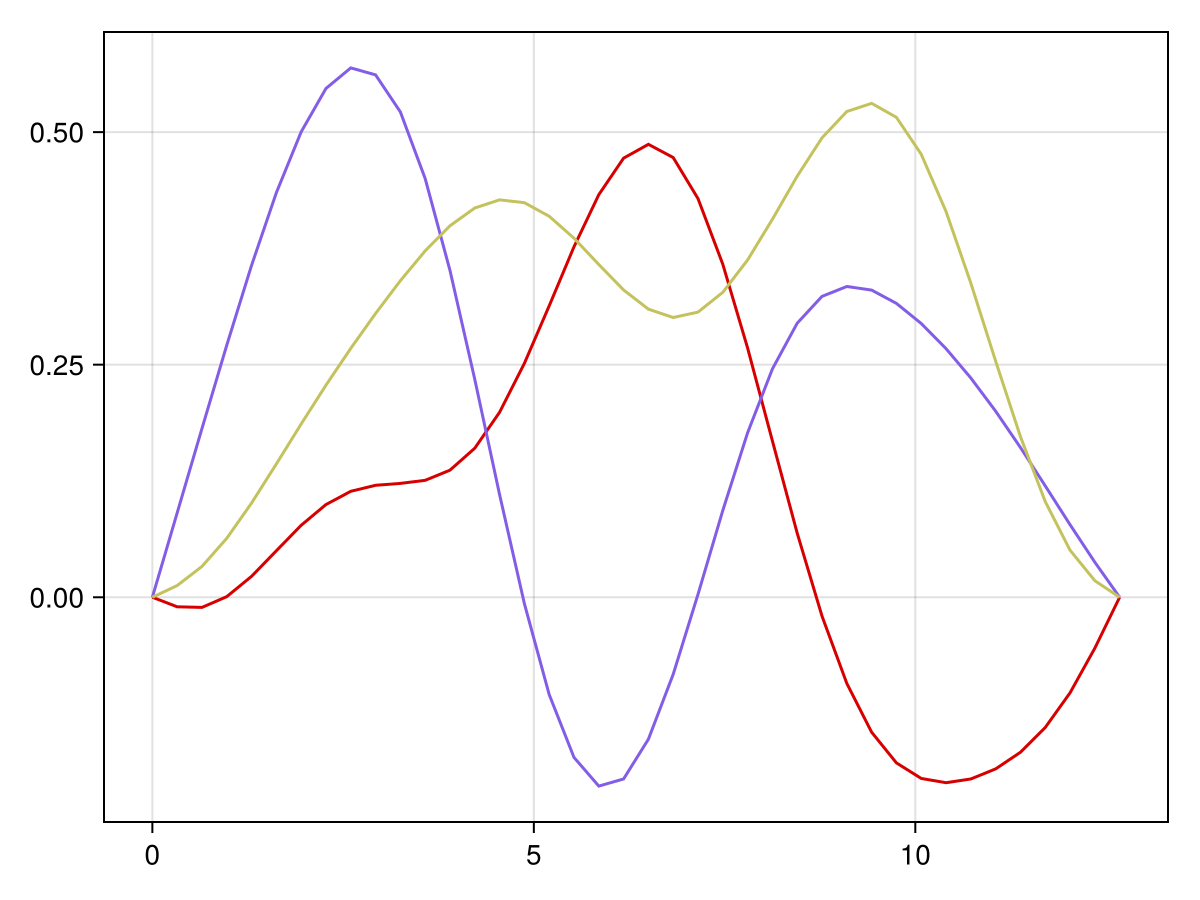

CairoMakie.Screen{IMAGE}


In [53]:
display(CairoMakie.plot(def.trajectory, :a))
display(CairoMakie.plot(add_prob.trajectory, :a))
display(CairoMakie.plot(varadd_prob.trajectory, :a))
display(CairoMakie.plot(f_uni_prob.trajectory, :a))

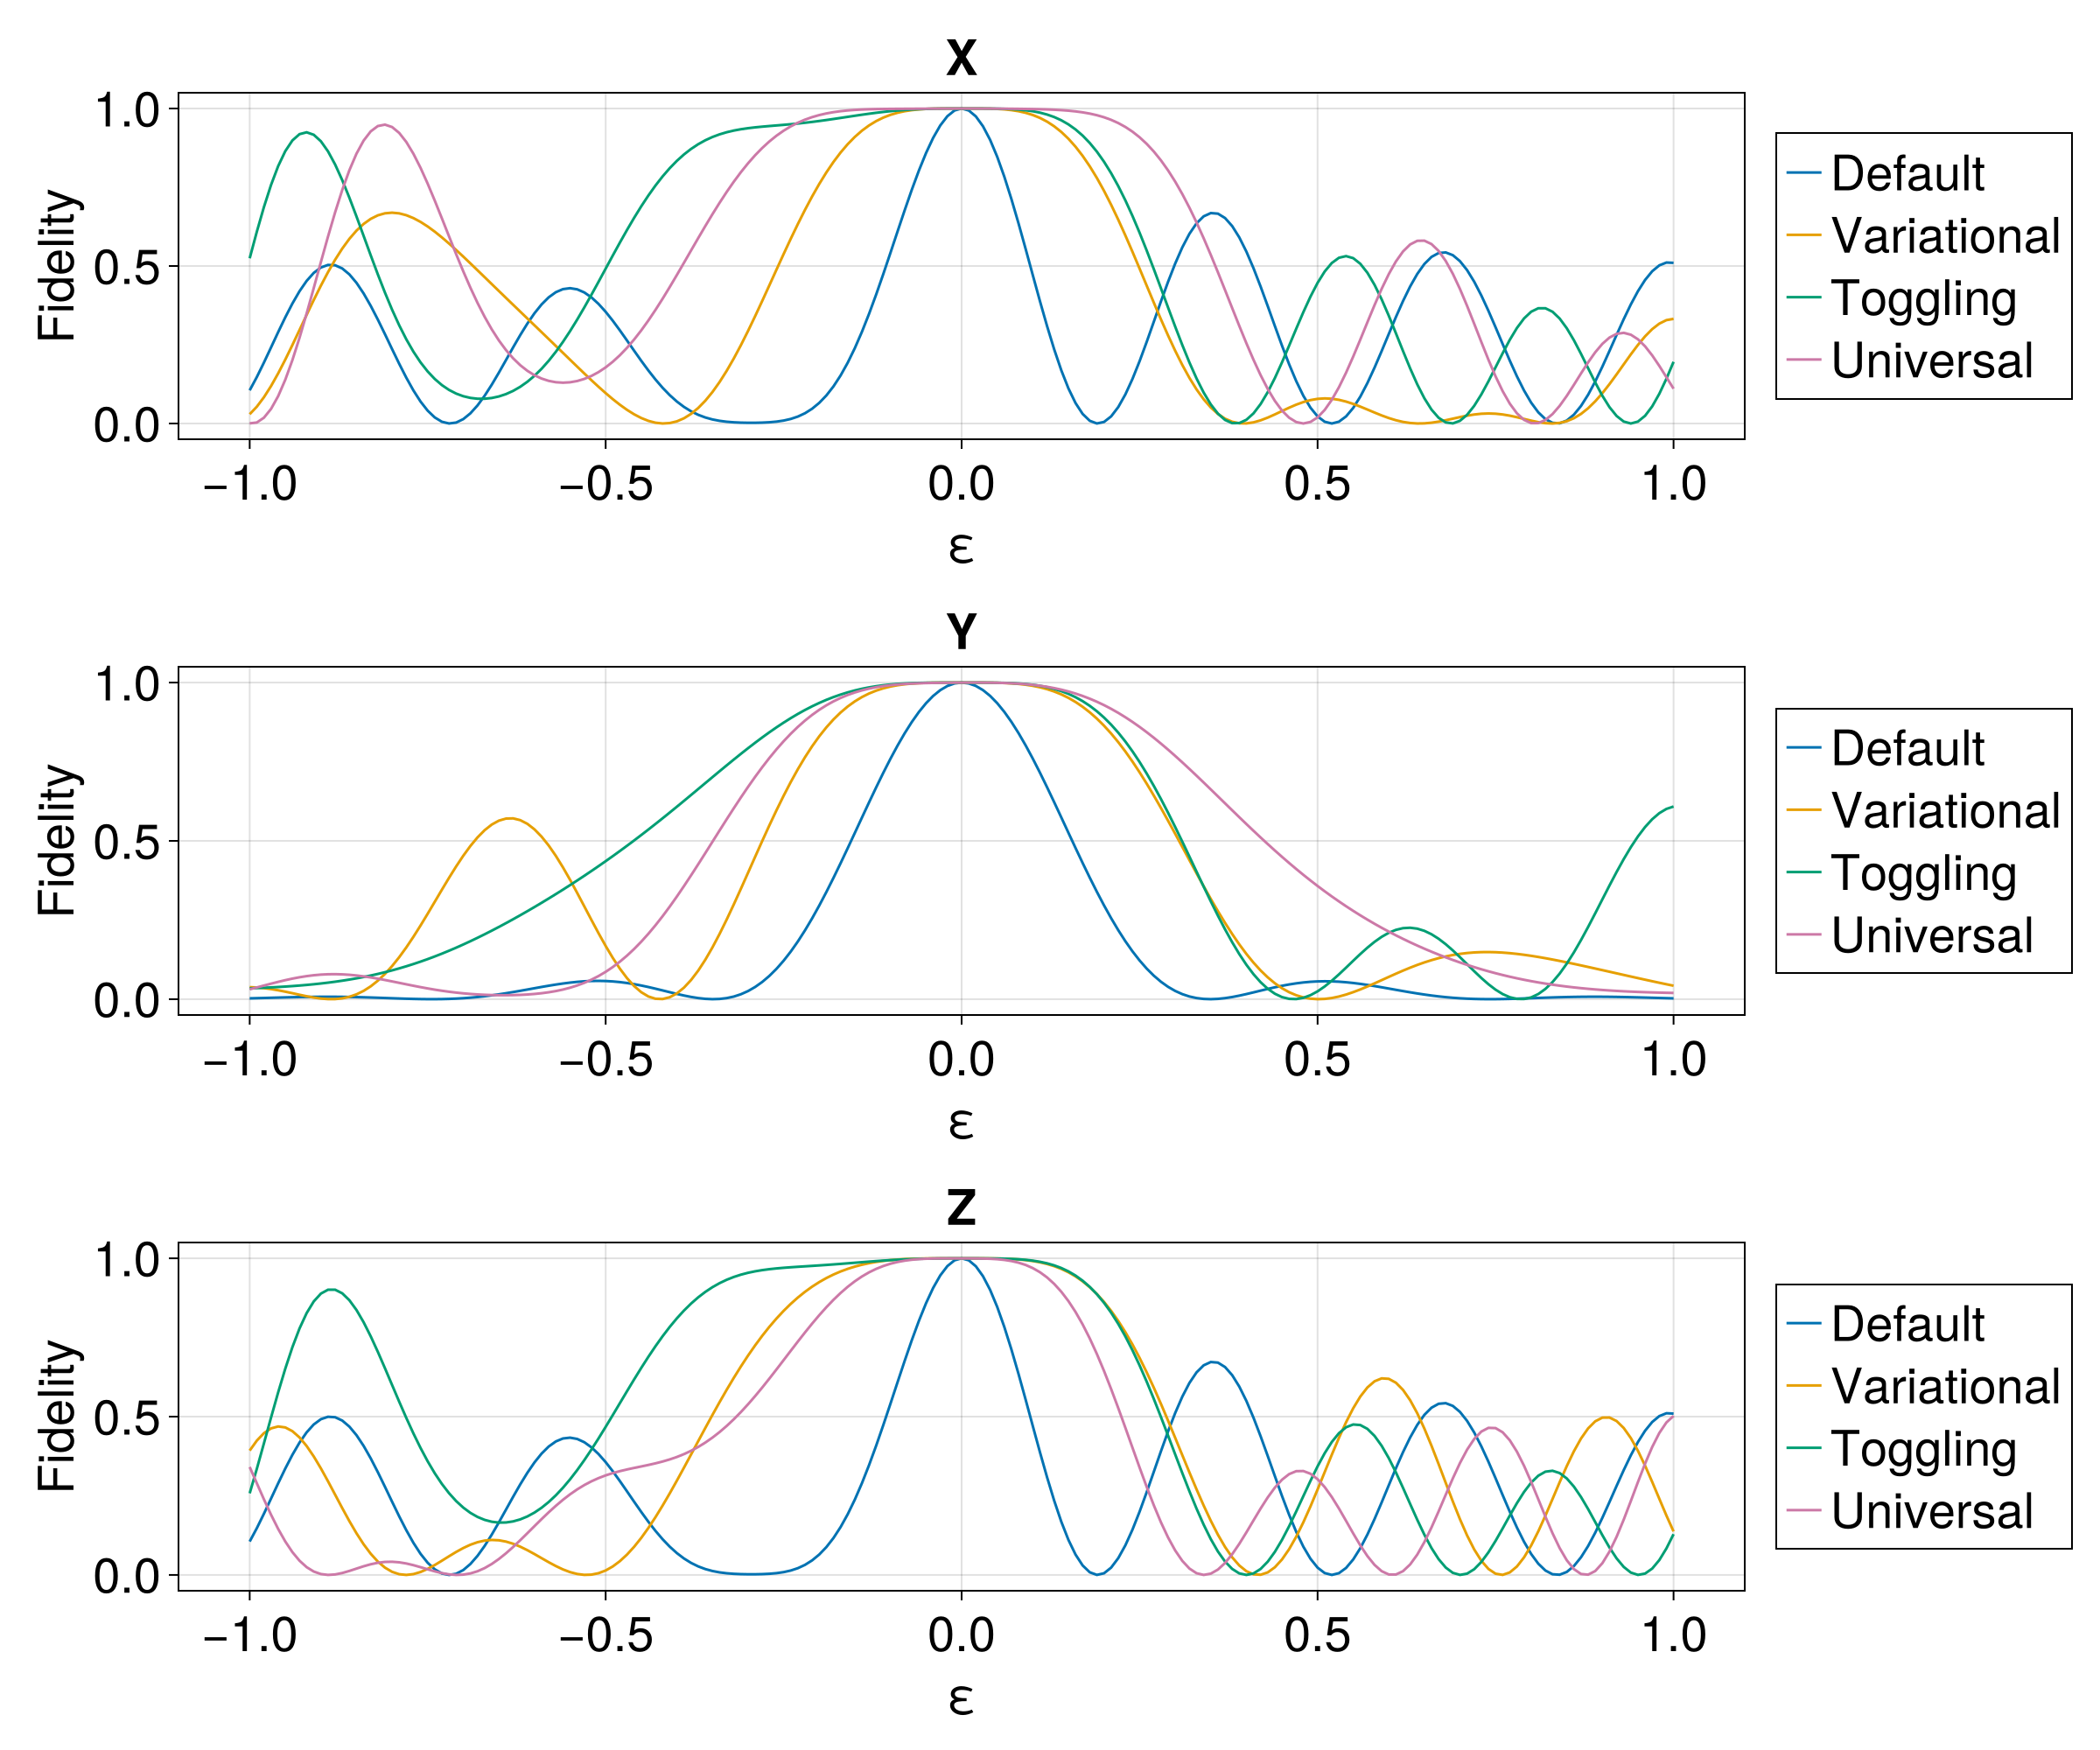

In [54]:
H_drive_add = H_drive  # (kept from your snippet, though it's unused below)

f = Figure(fontsize = 28, size = (1200, 1000))
axX = Axis(f[1, 1], title = "X", xlabel = "ε", ylabel = "Fidelity")
axY = Axis(f[2, 1], title = "Y", xlabel = "ε", ylabel = "Fidelity")
axZ = Axis(f[3, 1], title = "Z", xlabel = "ε", ylabel = "Fidelity")

colors = Makie.wong_colors()
εs = -1:0.01:1

basis = [PAULIS.X, PAULIS.Y, PAULIS.Z]

axes_paulis = [
    (axX, PAULIS.X),
    (axY, PAULIS.Y),
    (axZ, PAULIS.Z),
]

problems = [
    (def,        "Default"),
    (varadd_prob, "Variational"),
    (add_prob, "Toggling"),
    (f_uni_prob,   "Universal"),
    # (f_uni_prob, "fast universal"),
    # (rf_uni_prob,"really fast universal"),
]

# Helper to compute the curve once per (problem, Pauli)
fidelity_curve(prob, pauli) = [unitary_rollout_fidelity(prob.trajectory, QuantumSystem(ε * pauli, basis)) for ε in εs]

# Plot everything with two compact loops
for (ax, pauli) in axes_paulis
    for (i, (prob, label)) in enumerate(problems)
        ys = fidelity_curve(prob, pauli)
        lines!(ax, εs, ys; label = label, color = colors[i], linestyle = :solid)
    end
end

Legend(f[1, 2], axX, position = :lb)
Legend(f[2, 2], axY, position = :lb)
Legend(f[3, 2], axZ, position = :lb)

f


# Verify first-order robustness with space curve approach

In [55]:
using NamedTrajectories

function SpaceCurve(traj::NamedTrajectory, U_goal::AbstractMatrix{<:Number}, Hₑ::AbstractMatrix{<:Number})
    T = traj.T
    first_order_terms = Vector{Matrix{ComplexF64}}(undef, T)
    first_order_integral = zeros(ComplexF64, size(U_goal))

    for i in 1:T
        U = iso_vec_to_operator(traj.Ũ⃗[:, i])
        first_order_integral += U' * Hₑ * U
        first_order_terms[i] = first_order_integral
    end
    d = size(U_goal)[1]
    space_curve = [[real(tr(GATES.X * first_order_terms[t] / (d * T))),
                    real(tr(GATES.Y * first_order_terms[t] / (d * T))),
                    real(tr(GATES.Z * first_order_terms[t] / (d * T)))] for t in 1:T]
    return space_curve
end

SpaceCurve (generic function with 1 method)

In [56]:
Hₑ = GATES.X
uni_traj = f_uni_prob.trajectory
default_traj = def.trajectory
add_traj = add_prob.trajectory
var_traj = varadd_prob.trajectory
uni_curve = SpaceCurve(uni_traj, U_goal, Hₑ)
default_curve = SpaceCurve(default_traj, U_goal, Hₑ)
var_curve = SpaceCurve(varadd_prob.trajectory, U_goal, Hₑ)
add_curve = SpaceCurve(add_traj, U_goal, Hₑ)

40-element Vector{Vector{Float64}}:
 [0.025, 0.0, 0.0]
 [0.05, 7.695631998732861e-23, 6.593286629599825e-24]
 [0.0749587838904294, -0.00037349885269193404, -0.001385498701732602]
 [0.09958430018782934, -0.0015733167301668718, -0.005526077559014112]
 [0.12307778807185307, -0.004109905990090976, -0.013688293391056107]
 [0.14392371403785445, -0.008445874388360206, -0.0267896976534237]
 [0.15987428838048007, -0.014809714278505953, -0.04495782304939709]
 [0.16834058912185185, -0.022975683593632657, -0.06701771345695391]
 [0.1672767072589953, -0.03214223695035446, -0.09025222498251173]
 [0.15625771249437276, -0.04107931365677939, -0.11083645418800955]
 ⋮
 [-0.08307386579976304, -0.049267274553651784, -0.17388846407535677]
 [-0.06184813146386079, -0.038757188555716374, -0.1658880665040079]
 [-0.04336084127786726, -0.03011463322888653, -0.15144762329347133]
 [-0.028896692324646193, -0.023230450073425436, -0.13225396630170633]
 [-0.018770132199128785, -0.018046424038552493, -0.10999236949423608

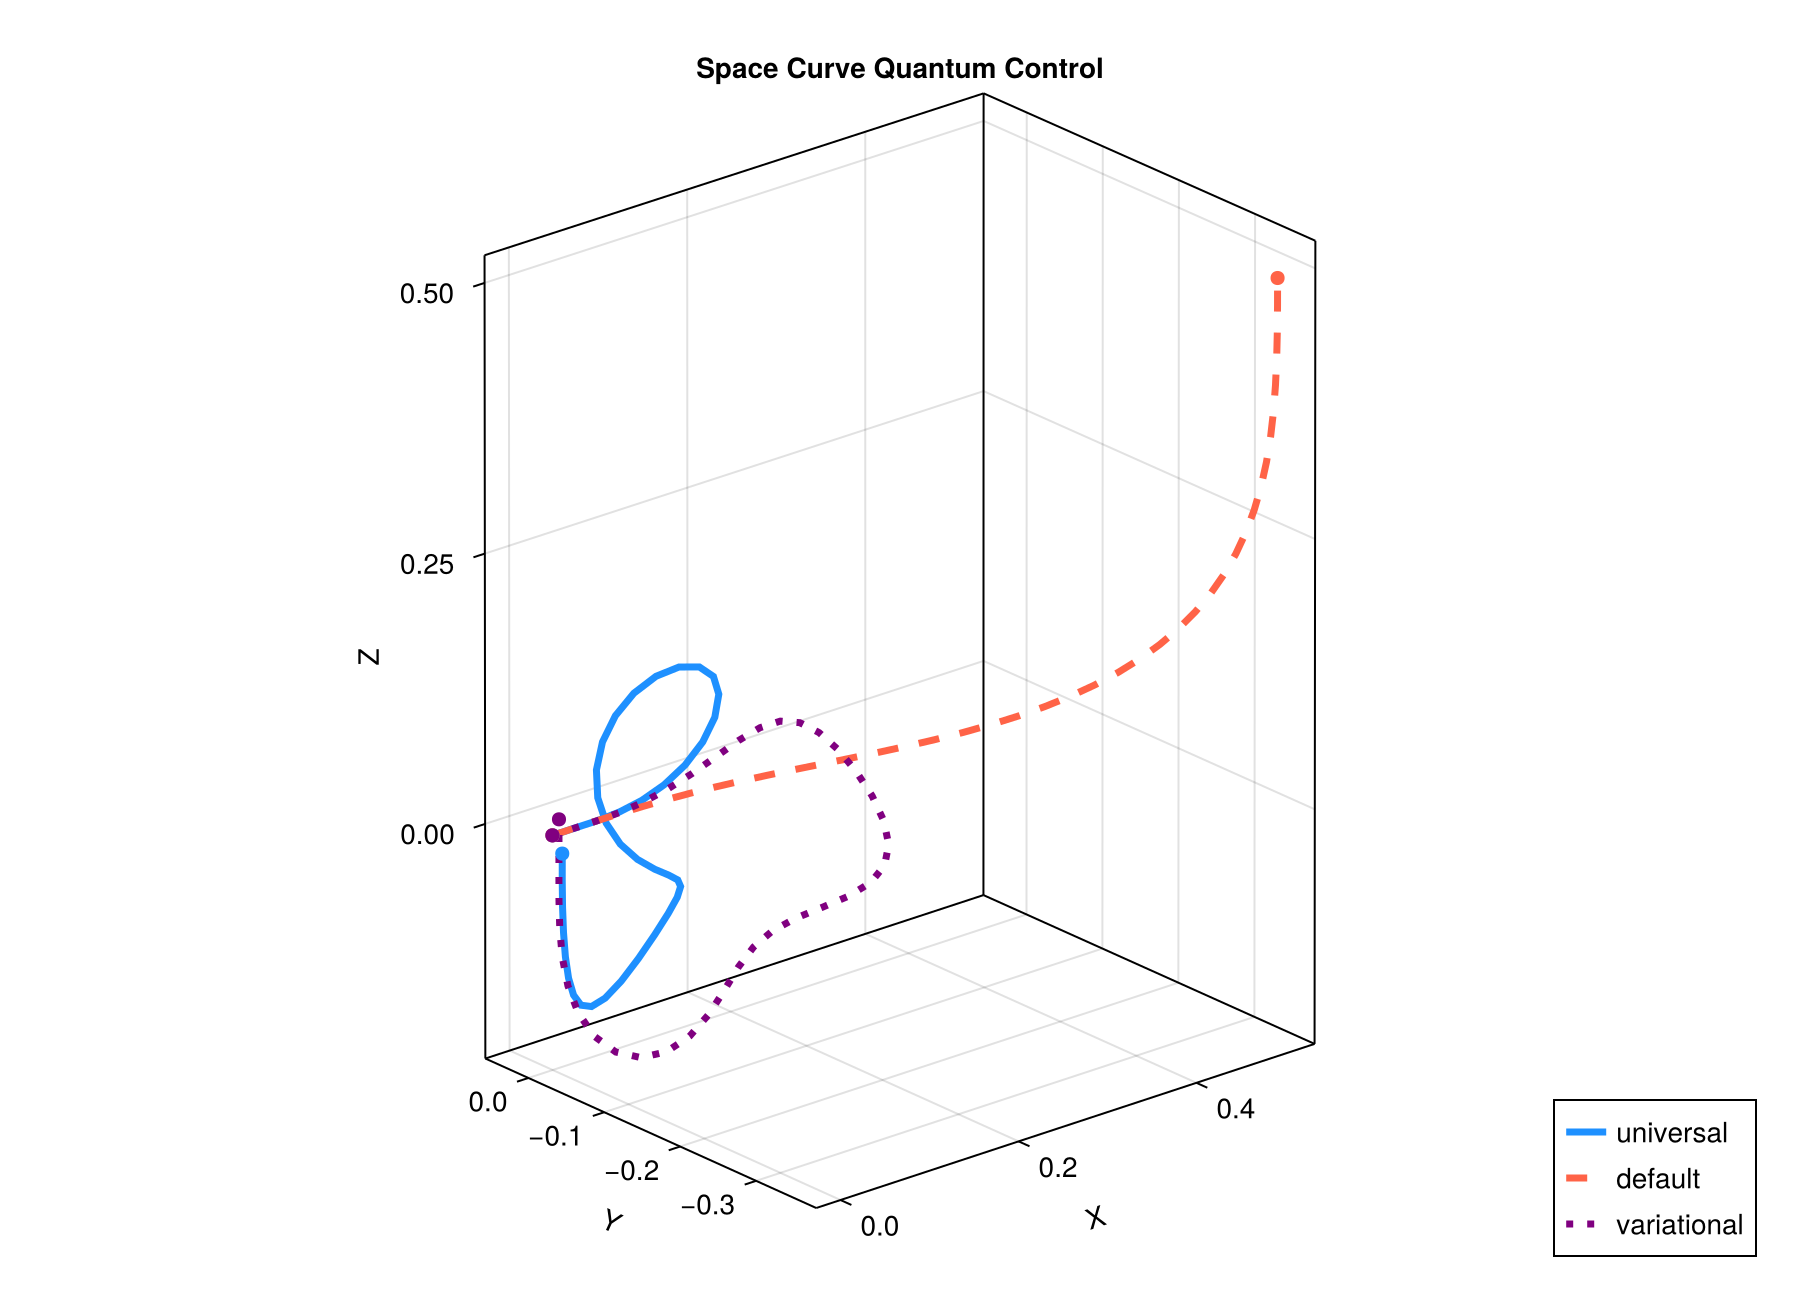

CairoMakie.Screen{IMAGE}


In [57]:
using CairoMakie
const CM = CairoMakie

function to_xyz(curve)
    if curve isa AbstractMatrix
        M = Float64.(real.(curve))
        if size(M, 2) == 3
            x, y, z = M[:, 1], M[:, 2], M[:, 3]
        elseif size(M, 1) == 3
            x, y, z = M[1, :], M[2, :], M[3, :]
        else
            error("Matrix curve must be T×3 or 3×T, got $(size(M))")
        end
    else
        x = Float64.(real.(getindex.(curve, 1)))
        y = Float64.(real.(getindex.(curve, 2)))
        z = Float64.(real.(getindex.(curve, 3)))
    end
    mask = isfinite.(x) .& isfinite.(y) .& isfinite.(z)
    return x[mask], y[mask], z[mask]
end

Hₑ = PAULIS.X

uni_curve     = SpaceCurve(uni_traj, U_goal, Hₑ)
default_curve = SpaceCurve(default_traj, U_goal, Hₑ)

x1, y1, z1 = to_xyz(uni_curve)
x2, y2, z2 = to_xyz(default_curve)
x3, y3, z3 = to_xyz(var_curve)

pushfirst!(x1, 0.0)
pushfirst!(y1, 0.0)
pushfirst!(z1, 0.0)
pushfirst!(x2, 0.0)
pushfirst!(y2, 0.0)
pushfirst!(z2, 0.0)
pushfirst!(x3, 0.0)
pushfirst!(y3, 0.0)
pushfirst!(z3, 0.0)

f  = CM.Figure(size = (900, 650))
ax = CM.Axis3(f[1, 1];
    xlabel = "X", ylabel = "Y", zlabel = "Z",
    title = "Space Curve Quantum Control", aspect = :data
)

CM.lines!(ax, x1, y1, z1; linewidth = 3.5, color = :dodgerblue, label = "universal")
CM.lines!(ax, x2, y2, z2; linewidth = 3.5, linestyle = :dash, color = :tomato, label = "default")
CM.lines!(ax, x3, y3, z3; linewidth = 3.5, linestyle = :dot, color = :purple, label = "variational")

CM.scatter!(ax, [x1[1]],  [y1[1]],  [z1[1]];  markersize = 10, color = :dodgerblue)
CM.scatter!(ax, [x1[end]],[y1[end]],[z1[end]]; markersize = 10, color = :dodgerblue)
CM.scatter!(ax, [x2[1]],  [y2[1]],  [z2[1]];  markersize = 10, color = :tomato)
CM.scatter!(ax, [x2[end]],[y2[end]],[z2[end]]; markersize = 10, color = :tomato)
CM.scatter!(ax, [x3[1]],  [y3[1]],  [z3[1]];  markersize = 10, color = :purple)
CM.scatter!(ax, [x3[end]],[y3[end]],[z3[end]]; markersize = 10, color = :purple)

CM.axislegend(ax; position = :rb)

display(f)

     

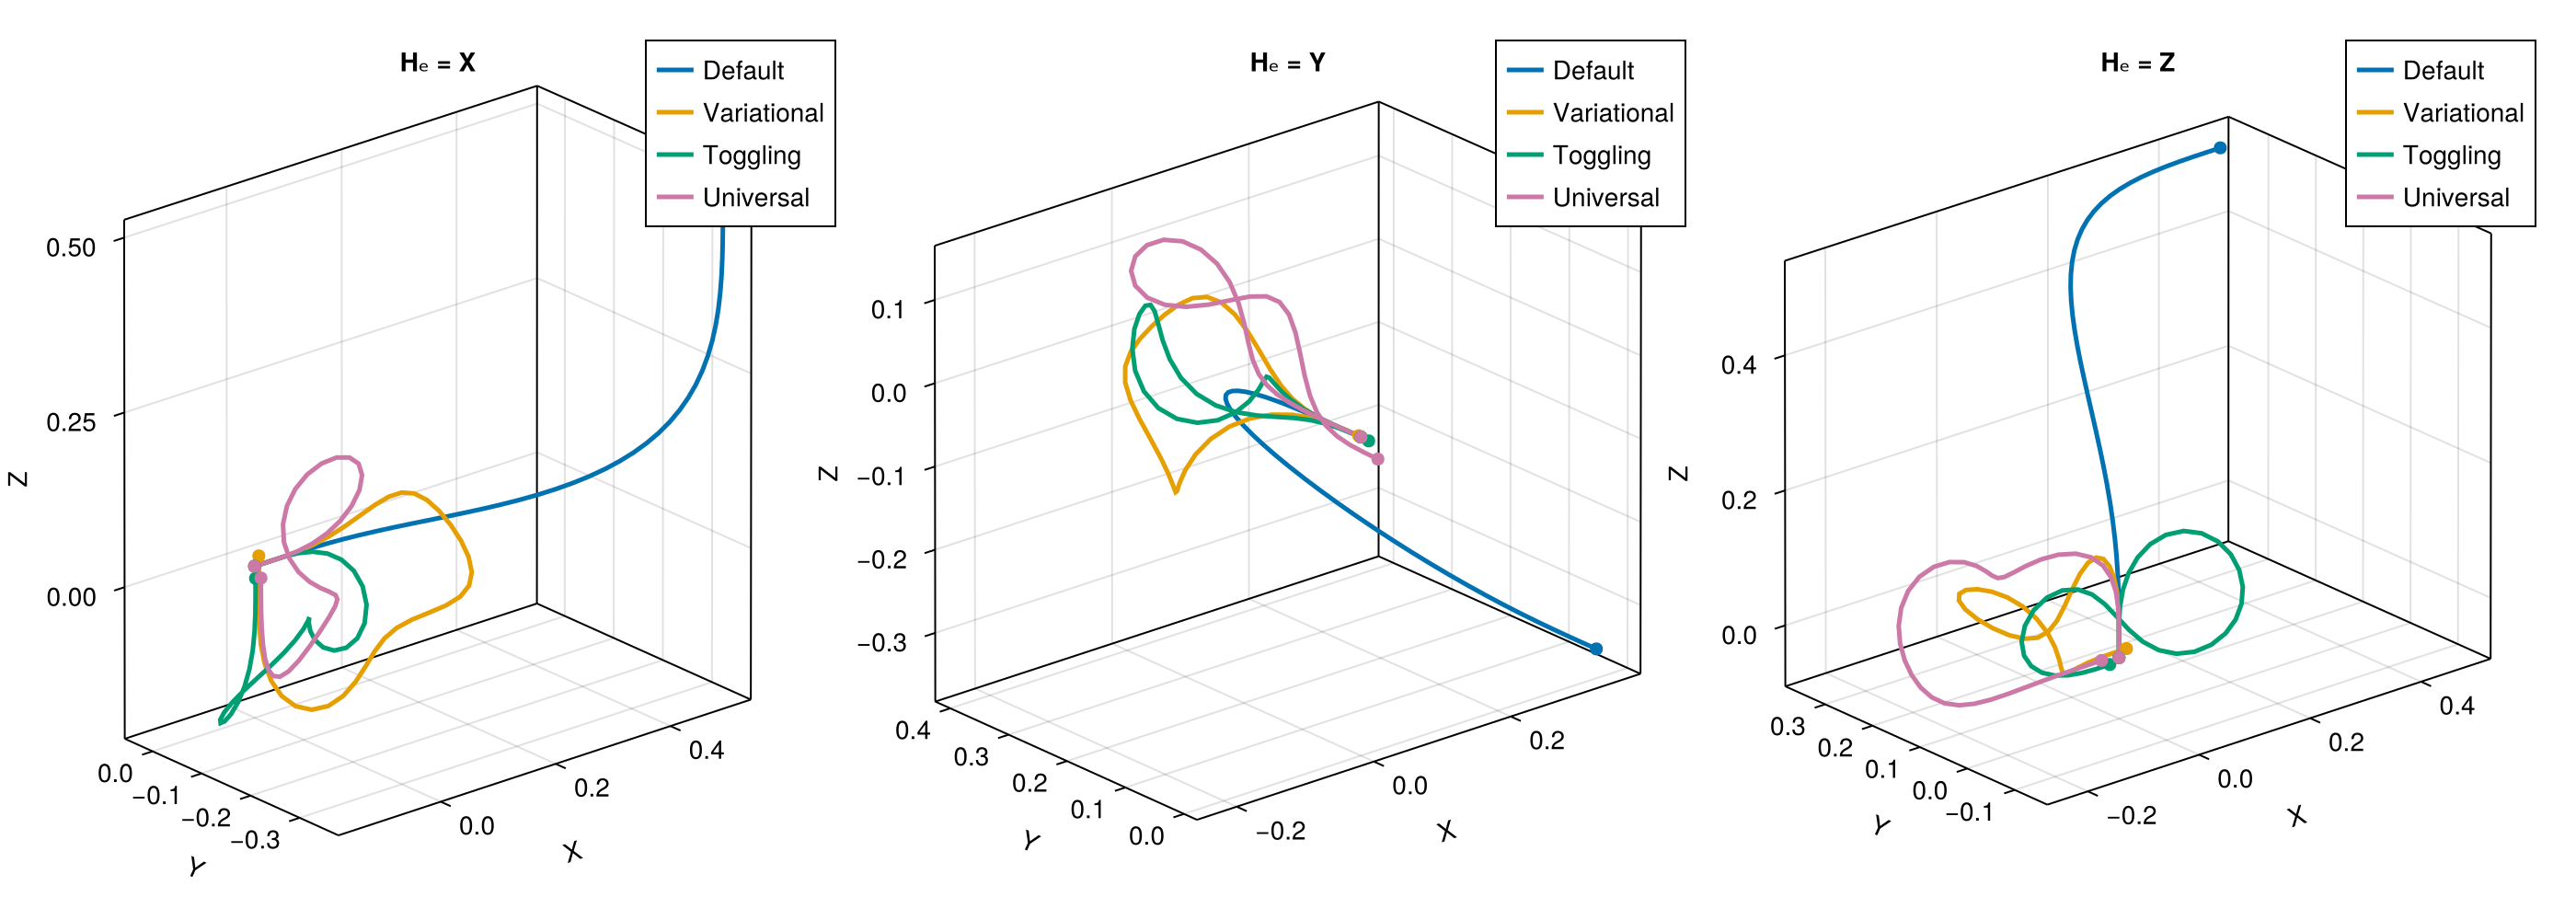

CairoMakie.Screen{IMAGE}


In [58]:
using CairoMakie
const CM = CairoMakie

function curves_for(Hₑ)
    uni_curve     = SpaceCurve(uni_traj,     U_goal, Hₑ)
    default_curve = SpaceCurve(default_traj, U_goal, Hₑ)
    var_curve    = SpaceCurve(varadd_prob.trajectory, U_goal, Hₑ)
    add_curve = SpaceCurve(add_traj, U_goal, Hₑ)
    return uni_curve, default_curve, var_curve, add_curve
end

function plot_pair!(pos, He_sym, ttl)
    colors = Makie.wong_colors()

    uni_curve, default_curve, var_curve, add_curve = curves_for(He_sym)

    x1,y1,z1 = to_xyz(default_curve)
    x2,y2,z2 = to_xyz(var_curve)
    x3,y3,z3 = to_xyz(add_curve)
    x4,y4,z4 = to_xyz(uni_curve)

    pushfirst!(x1,0.0); pushfirst!(y1,0.0); pushfirst!(z1,0.0)
    pushfirst!(x2,0.0); pushfirst!(y2,0.0); pushfirst!(z2,0.0)
    pushfirst!(x3,0.0); pushfirst!(y3,0.0); pushfirst!(z3,0.0)
    pushfirst!(x4,0.0); pushfirst!(y4,0.0); pushfirst!(z4,0.0)

    ax = CM.Axis3(pos; xlabel="X", ylabel="Y", zlabel="Z", title=ttl, aspect=:data)
    CM.lines!(ax, x1,y1,z1; linewidth=2.5, color=colors[1], label="Default")
    CM.lines!(ax, x2,y2,z2; linewidth=2.5, color=colors[2], label="Variational")
    CM.lines!(ax, x3,y3,z3; linewidth=2.5, color=colors[3], label="Toggling")
    CM.lines!(ax, x4,y4,z4; linewidth=2.5, color=colors[4], label="Universal")
    CM.scatter!(ax, [x1[1]], [y1[1]], [z1[1]]; markersize=10, color=colors[1])
    CM.scatter!(ax, [x1[end]], [y1[end]], [z1[end]]; markersize=10, color=colors[1])
    CM.scatter!(ax, [x2[1]], [y2[1]], [z2[1]]; markersize=10, color=colors[2])
    CM.scatter!(ax, [x2[end]], [y2[end]], [z2[end]]; markersize=10, color=colors[2])
    CM.scatter!(ax, [x3[1]], [y3[1]], [z3[1]]; markersize=10, color=colors[3])
    CM.scatter!(ax, [x3[end]], [y3[end]], [z3[end]]; markersize=10, color=colors[3])
    CM.scatter!(ax, [x4[1]], [y4[1]], [z4[1]]; markersize=10, color=colors[4])
    CM.scatter!(ax, [x4[end]], [y4[end]], [z4[end]]; markersize=10, color=colors[4])
    CM.axislegend(ax; position=:rt)
    return ax
end

f = CM.Figure(size=(1400, 500))
plot_pair!(f[1,1], PAULIS.X, "Hₑ = X")
plot_pair!(f[1,2], PAULIS.Y, "Hₑ = Y")
plot_pair!(f[1,3], PAULIS.Z, "Hₑ = Z")
display(f)

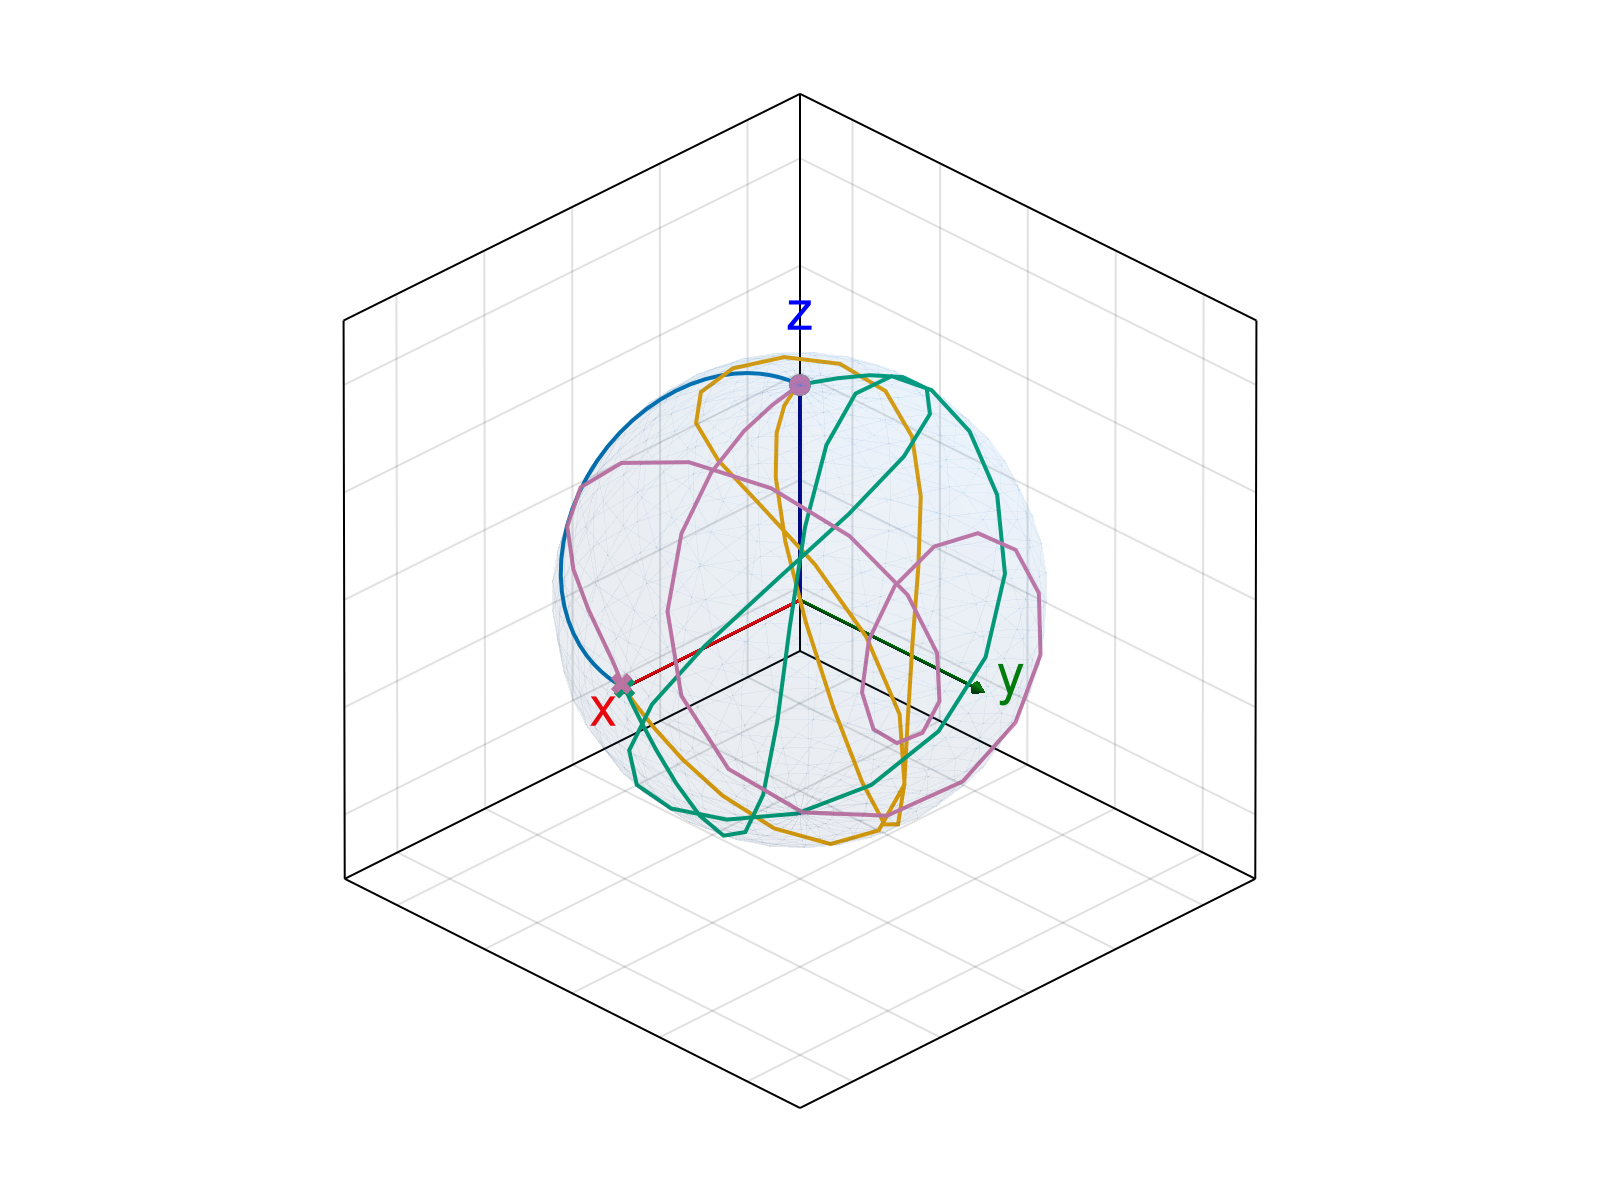

In [59]:
using CairoMakie
using GeometryBasics

ket_0 = [1.0,0.0]
traj_vec = [default_traj, var_traj, add_traj, uni_traj]
labels = ["Default", "Variational", "Toggling", "Universal"]
rho_0 = ket_0 * ket_0'

f  = CairoMakie.Figure(resolution = (800, 600))
ax = CairoMakie.Axis3(f[1, 1];
    aspect = :equal
)

palette = to_colormap(:tab10)
styles  = (:solid, :dash, :dot, :dashdot)

origins = [Point3f(0,0,0), Point3f(0,0,0), Point3f(0,0,0)]
dirs    = [Vec3f(1.0,0,0), Vec3f(0,1.0,0), Vec3f(0,0,1.0)]

CairoMakie.arrows!(ax, origins, dirs;
    color = [:red, :green, :blue],
    arrowsize = 0.05,
    linewidth = 0.01
)

CairoMakie.text!(ax, "x", position = Point3f(1.2, 0, 0), align = (:left, :center),  color = :red,   fontsize = 28)
CairoMakie.text!(ax, "y", position = Point3f(0, 1.2, 0), align = (:center, :bottom), color = :green, fontsize = 28)
CairoMakie.text!(ax, "z", position = Point3f(0, 0, 1.2), align = (:center, :bottom), color = :blue,  fontsize = 28)

for (i, traj) in enumerate(traj_vec)
    expect_val_x = [real(tr(PAULIS.X * iso_vec_to_operator(traj.Ũ⃗[:, t]) * rho_0 * iso_vec_to_operator(traj.Ũ⃗[:, t])')) for t in 1:traj.T]
    expect_val_y = [real(tr(PAULIS.Y * iso_vec_to_operator(traj.Ũ⃗[:, t]) * rho_0 * iso_vec_to_operator(traj.Ũ⃗[:, t])')) for t in 1:traj.T]
    expect_val_z = [real(tr(PAULIS.Z * iso_vec_to_operator(traj.Ũ⃗[:, t]) * rho_0 * iso_vec_to_operator(traj.Ũ⃗[:, t])')) for t in 1:traj.T]

    CairoMakie.lines!(ax, real.(expect_val_x), real.(expect_val_y), real.(expect_val_z);
        color = colors[i],
        label = labels[i],
        #linestyle = styles[i],
        linewidth = 2.0
    )

    CairoMakie.scatter!(ax, [real(expect_val_x[end])], [real(expect_val_y[end])], [real(expect_val_z[end])];
        color = colors[i], markersize = 15, marker = :xcross)
    CairoMakie.scatter!(ax, [real(expect_val_x[1])], [real(expect_val_y[1])], [real(expect_val_z[1])];
        color = colors[i], markersize = 15)

end
CairoMakie.mesh!(ax, Sphere(Point3f(0,0,0), 1f0);
    color = (0.2, 0.6, 1.0, 0.05),
    transparency = true,
    shading = true
)

CairoMakie.xlims!(ax, -1.3, 1.3)
CairoMakie.ylims!(ax, -1.3, 1.3)
CairoMakie.zlims!(ax, -1.3, 1.3)

ax.azimuth[]   =  π/4
ax.elevation[] =  π/6

#CairoMakie.axislegend(ax; position = :rt, fontsize=40)
CairoMakie.hidexdecorations!(ax, grid = false)
CairoMakie.hideydecorations!(ax, grid = false)
CairoMakie.hidezdecorations!(ax, grid = false)

f
     

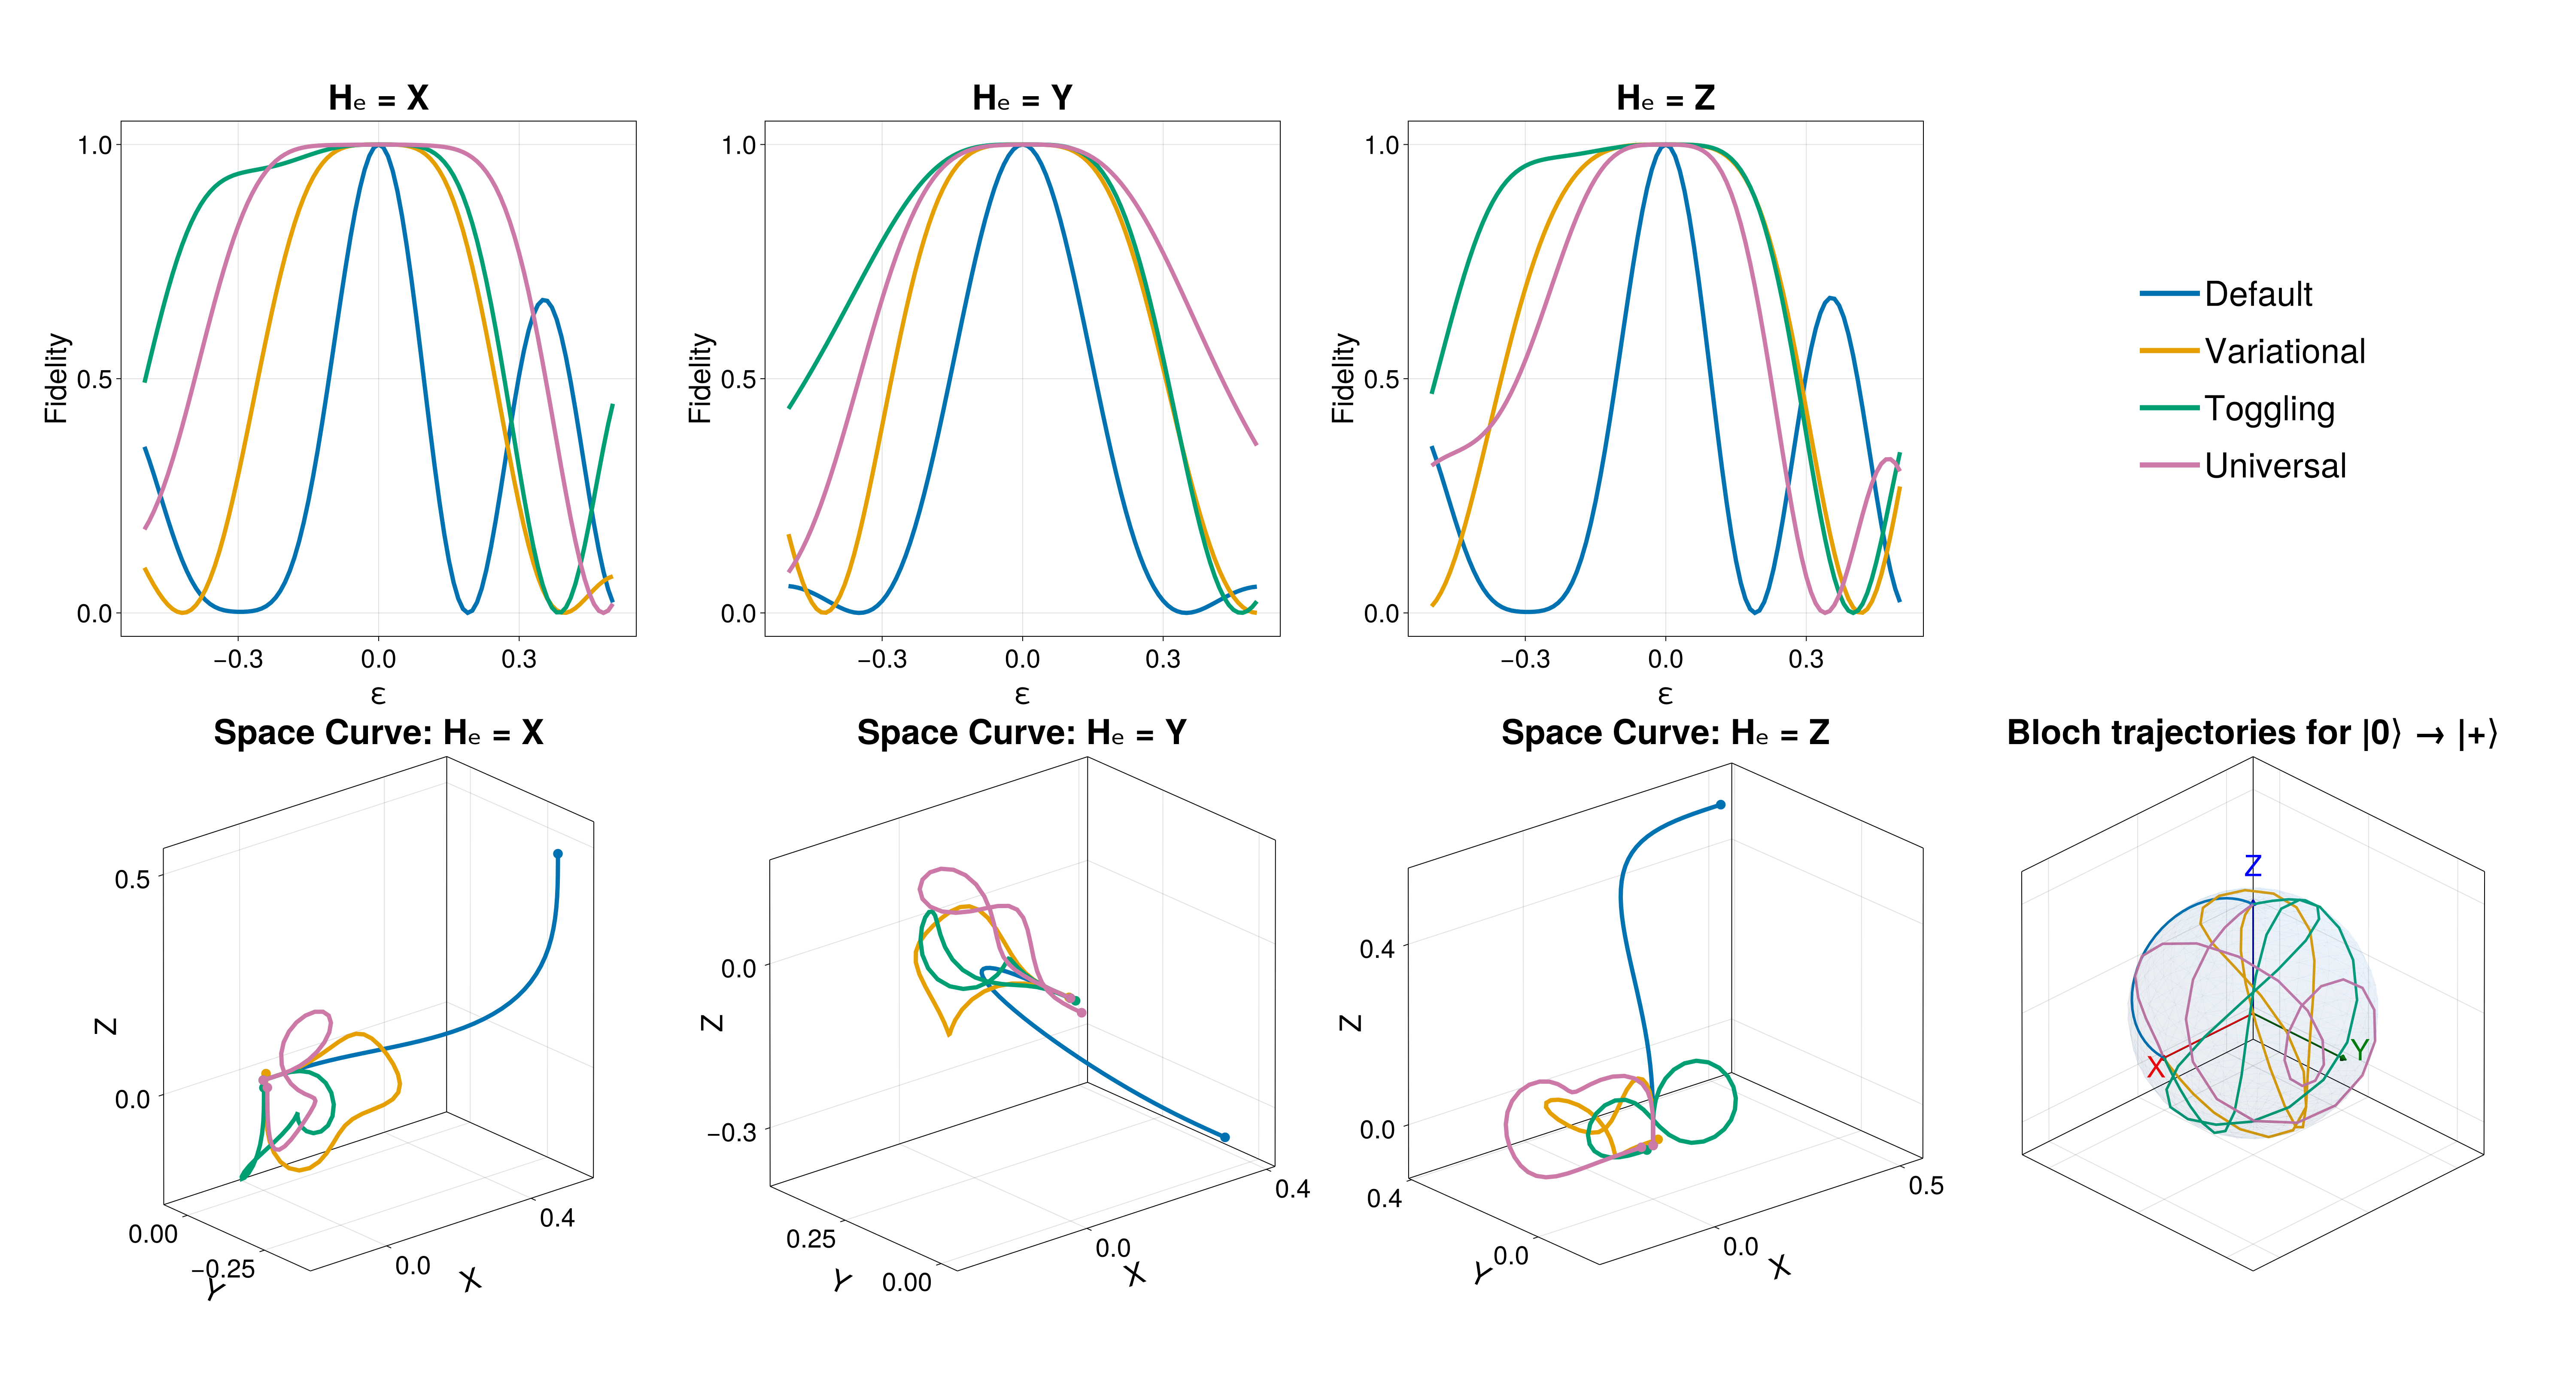

33

In [60]:
using CairoMakie
using GeometryBasics
const CM = CairoMakie

# ----------------------------
# Consistent palette & problems
# ----------------------------
colors = Makie.wong_colors()

problems = [
    (def,          "Default"),     # colors[1]
    (varadd_prob,  "Variational"), # colors[2]
    (add_prob,     "Toggling"),    # colors[3]
    (f_uni_prob,   "Universal"),   # colors[4]
]
labels = [p[2] for p in problems]

# Pauli basis for the error Hamiltonian construction
basis = [PAULIS.X, PAULIS.Y, PAULIS.Z]

# Sweep values
εs = -0.5:0.01:0.5

# Compute fidelity curve for given problem & Pauli
fidelity_curve(prob, pauli) = [
    unitary_rollout_fidelity(
        prob.trajectory,
        QuantumSystem(ε * pauli, basis)
    ) for ε in εs
]

# ------------------------------------------------
# Robust autolims for 3D axes (accepts Real arrays)
# ------------------------------------------------
function autolims3!(
    ax::Axis3,
    xyzs::AbstractVector{<:Tuple{
        AbstractVector{<:Real},
        AbstractVector{<:Real},
        AbstractVector{<:Real}
    }};
    pad = 0.08
)
    xs = reduce(vcat, (x for (x, _, _) in xyzs))
    ys = reduce(vcat, (y for (_, y, _) in xyzs))
    zs = reduce(vcat, (z for (_, _, z) in xyzs))

    xmin, xmax = extrema(xs); ymin, ymax = extrema(ys); zmin, zmax = extrema(zs)
    dx = xmax - xmin; dy = ymax - ymin; dz = zmax - zmin
    px = max(eps(), dx * pad); py = max(eps(), dy * pad); pz = max(eps(), dz * pad)

    CM.xlims!(ax, xmin - px, xmax + px)
    CM.ylims!(ax, ymin - py, ymax + py)
    CM.zlims!(ax, zmin - pz, zmax + pz)
    return ax
end

# ---------------------------------------
# One 3D panel for a given error operator
# ---------------------------------------
function plot_spacecurves_panel!(pos, He_sym, ttl; width=nothing, height=nothing)
    # Expect user env to define:
    #   curves_for(He_sym) -> (uni_curve, default_curve, var_curve, add_curve)
    #   to_xyz(curve) -> (x, y, z)
    uni_curve, default_curve, var_curve, add_curve = curves_for(He_sym)

    # Order matches colors: Default, Variational, Toggling, Universal
    x1,y1,z1 = to_xyz(default_curve)
    x2,y2,z2 = to_xyz(var_curve)
    x3,y3,z3 = to_xyz(add_curve)
    x4,y4,z4 = to_xyz(uni_curve)

    # Anchor curves at origin
    for (x,y,z) in ((x1,y1,z1),(x2,y2,z2),(x3,y3,z3),(x4,y4,z4))
        pushfirst!(x,0.0); pushfirst!(y,0.0); pushfirst!(z,0.0)
    end

    ax = CM.Axis3(pos; title=ttl,
        xlabel="X", ylabel="Y", zlabel="Z",
        aspect=:data, width=width, height=height,
        titlesize=40, xlabelsize=34, ylabelsize=34, zlabelsize=34,
        xticklabelsize=30, yticklabelsize=30, zticklabelsize=30,
        # Nudges labels away from tick clutter
        xlabeloffset=48, ylabeloffset=48, zlabeloffset=48,
        # Fewer ticks to avoid crowding
        xticks = LinearTicks(2), yticks = LinearTicks(2), zticks = LinearTicks(2)
    )

    # Auto-scale so curves fill the axes nicely
    all_xyz = [(x1,y1,z1), (x2,y2,z2), (x3,y3,z3), (x4,y4,z4)]
    autolims3!(ax, all_xyz; pad=0.10)

    # Draw curves + start/end markers
    for (x,y,z,col) in [(x1,y1,z1,colors[1]), (x2,y2,z2,colors[2]),
                        (x3,y3,z3,colors[3]), (x4,y4,z4,colors[4])]
        CM.lines!(ax, x,y,z; linewidth=5.0, color=col)
        CM.scatter!(ax, [first(x)], [first(y)], [first(z)];
                    color=col, markersize=16, marker=:circle)
        CM.scatter!(ax, [last(x)], [last(y)], [last(z)];
                    color=col, markersize=16, marker=:circle)
    end

    return ax
end

# ---------------------------------------
# Bloch trajectories panel (no scatter)
# ---------------------------------------
function plot_bloch_panel!(pos; width=nothing, height=nothing)
    ket_0 = [1.0,0.0]
    rho_0 = ket_0 * ket_0'

    traj_vec = [default_traj, var_traj, add_traj, uni_traj]
    lbls     = ["Default","Variational","Toggling","Universal"]

    ax = CM.Axis3(pos; aspect=:equal, title="Bloch trajectories for |0⟩ → |+⟩",
        width=width, height=height,
        titlesize=40, xlabelsize=34, ylabelsize=34, zlabelsize=34,
        xticklabelsize=30, yticklabelsize=30, zticklabelsize=30,
        xlabel="X", ylabel="Y", zlabel="Z",
        xlabeloffset=48, ylabeloffset=48, zlabeloffset=48,
        xticks = LinearTicks(2), yticks = LinearTicks(2), zticks = LinearTicks(2)
    )

    # Axis arrows
    origins = [Point3f(0,0,0), Point3f(0,0,0), Point3f(0,0,0)]
    dirs    = [Vec3f(1.0,0,0), Vec3f(0,1.0,0), Vec3f(0,0,1.0)]
    CM.arrows!(ax, origins, dirs; color=[:red,:green,:blue], arrowsize=0.05, linewidth=0.01)
    CM.text!(ax, "X", position=Point3f(1.2,0,0), align=(:left,:center),  color=:red,   fontsize=34)
    CM.text!(ax, "Y", position=Point3f(0,1.2,0), align=(:center,:bottom),color=:green, fontsize=34)
    CM.text!(ax, "Z", position=Point3f(0,0,1.2), align=(:center,:bottom),color=:blue,  fontsize=34)

    # Draw lines only (no start/end markers)
    for (i, traj) in enumerate(traj_vec)
        ex = [real(tr(PAULIS.X * iso_vec_to_operator(traj.Ũ⃗[:, t]) * rho_0 *
                     iso_vec_to_operator(traj.Ũ⃗[:, t])')) for t in 1:traj.T]
        ey = [real(tr(PAULIS.Y * iso_vec_to_operator(traj.Ũ⃗[:, t]) * rho_0 *
                     iso_vec_to_operator(traj.Ũ⃗[:, t])')) for t in 1:traj.T]
        ez = [real(tr(PAULIS.Z * iso_vec_to_operator(traj.Ũ⃗[:, t]) * rho_0 *
                     iso_vec_to_operator(traj.Ũ⃗[:, t])')) for t in 1:traj.T]
        CM.lines!(ax, ex, ey, ez; color=colors[i], linewidth=3.0, label=lbls[i])
    end

    # Bloch sphere shell
    CM.mesh!(ax, Sphere(Point3f(0,0,0), 1f0); color=(0.2,0.6,1.0,0.05), transparency=true, shading=true)

    # Nice limits & view
    CM.xlims!(ax, -1.3, 1.3); CM.ylims!(ax, -1.3, 1.3); CM.zlims!(ax, -1.3, 1.3)
    ax.azimuth[] =  π/4; ax.elevation[] = π/6

    # Hide ticks grids (axes labels remain)
    CM.hidexdecorations!(ax, grid=false)
    CM.hideydecorations!(ax, grid=false)
    CM.hidezdecorations!(ax, grid=false)

    return ax
end

# ----------------
# Build full figure
# ----------------
fig = CM.Figure(size=(3000, 1600), fontsize=32, padding=60)


# Sizes
TOP_SQ = 600           # width & height for the top square panels
BOT_WH = (600, 600)    # width, height for the space-curve panels
BLOCH_WH = (600, 600)  # width, height for Bloch panel (bigger so it’s not tiny)

# ---- Top row (2D sweeps for X, Y, Z) ----
axX = CM.Axis(fig[1, 1]; title="Hₑ = X", xlabel="ε", ylabel="Fidelity",
    width=TOP_SQ, height=TOP_SQ, titlesize=40, xlabelsize=34, ylabelsize=34,
    xticklabelsize=30, yticklabelsize=30)
axY = CM.Axis(fig[1, 2]; title="Hₑ = Y", xlabel="ε", ylabel="Fidelity",
    width=TOP_SQ, height=TOP_SQ, titlesize=40, xlabelsize=34, ylabelsize=34,
    xticklabelsize=30, yticklabelsize=30)
axZ = CM.Axis(fig[1, 3]; title="Hₑ = Z", xlabel="ε", ylabel="Fidelity",
    width=TOP_SQ, height=TOP_SQ, titlesize=40, xlabelsize=34, ylabelsize=34,
    xticklabelsize=30, yticklabelsize=30)

for (ax, pauli) in [(axX, PAULIS.X), (axY, PAULIS.Y), (axZ, PAULIS.Z)]
    for (i, (prob, _label)) in enumerate(problems)
        ys = fidelity_curve(prob, pauli)
        CM.lines!(ax, εs, ys; color=colors[i], linewidth=5.0)
    end
end

# ---- Bottom row (3D space curves for X, Y, Z) ----
plot_spacecurves_panel!(fig[2, 1], PAULIS.X, "Space Curve: Hₑ = X";
    width=BOT_WH[1], height=BOT_WH[2])
plot_spacecurves_panel!(fig[2, 2], PAULIS.Y, "Space Curve: Hₑ = Y";
    width=BOT_WH[1], height=BOT_WH[2])
plot_spacecurves_panel!(fig[2, 3], PAULIS.Z, "Space Curve: Hₑ = Z";
    width=BOT_WH[1], height=BOT_WH[2])

# ---- Bloch trajectories (bottom-right) ----
plot_bloch_panel!(fig[2, 4]; width=BLOCH_WH[1], height=BLOCH_WH[2])

# ---- Global legend (top-right) ----
handles = [LineElement(color=colors[i], linewidth=6.0) for i in 1:length(problems)]
Legend(fig[1, 4], handles, labels;
    orientation=:vertical, framevisible=false,
    labelsize=40,                # legend text size
    titlesize=40,                # if you add a title later
    patchsize=(70, 34),          # bigger color swatches
    rowgap=20
)

# Layout: make columns 1–3 wide for panels, 4 for legend/Bloch
colsize!(fig.layout, 1, Auto(1.0))
colsize!(fig.layout, 2, Auto(1.0))
colsize!(fig.layout, 3, Auto(1.0))
colsize!(fig.layout, 4, Auto(0.95))  # roomy right column for legend + bloch
rowgap!(fig.layout, 24)
colgap!(fig.layout, 24)

display(fig)
idx = 33
#save("universal_robustness_hadamard_bloch_seed_$idx.png", fig; px_per_unit=2)  # optional